In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mu0 = 4 * np.pi * 1e-7  # [T m / A]

B_RESULTS_CSV_PATH = "B_results.csv"
METADATA_CSV_PATH = "B_results_metadata.csv"

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

In [ ]:
# ============================================================
# Load reconstructed pulse magnetic-field maps
# ============================================================

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "pixel", "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
    "Bx_odd_nT", "By_odd_nT", "Bz_odd_nT",
    "Bx_even_nT", "By_even_nT", "Bz_even_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"B_results.csv is missing columns: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

x_values_um = x_grid_um[0, :]
y_values_um = y_grid_um[:, 0]

dx_um = float(np.mean(np.diff(x_values_um)))
dy_um = float(np.mean(np.diff(y_values_um)))

dx_m = dx_um * 1e-6
dy_m = dy_um * 1e-6

extent_um = [
    float(np.nanmin(x_grid_um)),
    float(np.nanmax(x_grid_um)),
    float(np.nanmin(y_grid_um)),
    float(np.nanmax(y_grid_um)),
]

B_pos_nT = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_nT = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_nT = np.stack([
    B_df["Bx_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_odd_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_even_nT = np.stack([
    B_df["Bx_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_even_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

# ============================================================
# Load metadata
# ============================================================

metadata_df = pd.read_csv(METADATA_CSV_PATH)

def get_metadata_value(key, default=None, cast=float):
    matches = metadata_df.loc[metadata_df["key"] == key, "value"]

    if len(matches) == 0:
        print(f"Metadata key '{key}' not found. Using default: {default}")
        return default

    value = matches.iloc[0]

    if cast is None:
        return value

    try:
        return cast(value)
    except Exception:
        print(f"Could not cast metadata key '{key}' = {value}. Using default: {default}")
        return default

I_POS_mA = get_metadata_value("current_pos_mA", default=2.0, cast=float)
I_NEG_mA = get_metadata_value("current_neg_mA", default=-2.0, cast=float)
PULSE_AMPLITUDE_mV = get_metadata_value("pulse_amplitude_mV", default=10.0, cast=float)

print("Loaded B_results.csv")
print("--------------------")
print("grid size:", grid_size, "x", grid_size)
print("extent_um:", extent_um)
print(f"dx = {dx_um:.3f} µm")
print(f"dy = {dy_um:.3f} µm")

print("\nMetadata")
print("--------")
print(f"I_POS_mA = {I_POS_mA}")
print(f"I_NEG_mA = {I_NEG_mA}")
print(f"Pulse amplitude = {PULSE_AMPLITUDE_mV} mV")

Loaded B_results.csv
--------------------
grid size: 31 x 31
extent_um: [-100.0, 100.0, -100.0, 100.0]
dx = 6.667 µm
dy = 6.667 µm

Metadata
--------
I_POS_mA = 2.0
I_NEG_mA = -2.0
Pulse amplitude = 10.0 mV


In [ ]:
#geo setup same as in simulation 

WIRE_THETA_DEG = -5.0

WIRE_X0_UM = 20.0
WIRE_Y0_UM = 0.0

EFFECTIVE_HEIGHT_UM = 20.0

WIRE_LENGTH_UM = 500.0
WIRE_RADIUS_UM = 10.0

WIRE_CENTER_RAISE_UM = 10.0
WIRE_SIDE_BOW_UM = 5.0

SENSOR_Z_SIGN = -1.0

USE_LOCAL_KINK = True
WIRE_KINK_AMPLITUDE_UM = -10.0
WIRE_KINK_WIDTH_UM = 40.0
WIRE_KINK_CENTER_UM = 100.0

theta = np.deg2rad(WIRE_THETA_DEG)

# Unit vector parallel to nominal wire/current direction
u_x = np.sin(theta)
u_y = np.cos(theta)

# Unit vector perpendicular to the nominal wire direction
p_x = np.cos(theta)
p_y = -np.sin(theta)

print("Geometry used for current-density diagnostics")
print("---------------------------------------------")
print(f"WIRE_THETA_DEG = {WIRE_THETA_DEG}")
print(f"u_parallel = ({u_x:.4f}, {u_y:.4f})")
print(f"p_perp     = ({p_x:.4f}, {p_y:.4f})")
print(f"EFFECTIVE_HEIGHT_UM = {EFFECTIVE_HEIGHT_UM}")

Geometry used for current-density diagnostics
---------------------------------------------
WIRE_THETA_DEG = -5.0
u_parallel = (-0.0872, 0.9962)
p_perp     = (0.9962, 0.0872)
EFFECTIVE_HEIGHT_UM = 20.0


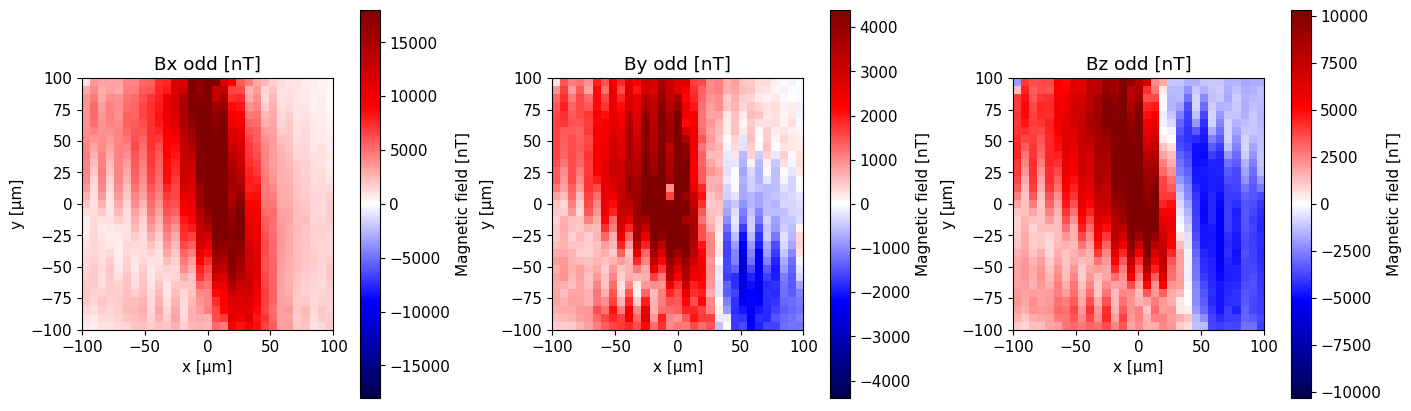

In [ ]:
# ============================================================
# Plot current-reversing odd magnetic field
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    data = B_odd_nT[i]

    lim = np.nanpercentile(np.abs(data), 95)
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im = axes[i].imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )

    axes[i].set_title(f"{comp} odd [nT]")
    axes[i].set_xlabel("x [µm]")
    axes[i].set_ylabel("y [µm]")
    plt.colorbar(im, ax=axes[i], label="Magnetic field [nT]")

plt.show()

# functions for reconstructin current, only Bz and from all components


In [ ]:
# ============================================================
# Function 1: reconstruct 2D sheet current from Bz only
# ============================================================

def reconstruct_current_from_Bz_only(
    Bz_nT,
    dx_m,
    dy_m,
    stand_off_um,
    k_filter_fraction=0.25,
):
    """
    Reconstruct equivalent 2D sheet current from Bz only.

    Assumptions
    -----------
    - Current is an equivalent 2D sheet current K(x,y) = (Kx, Ky).
    - Current is divergence-free:
          div K = 0
    - Therefore K can be written using a stream function g:
          Kx =  dg/dy
          Ky = -dg/dx
    - For a sheet current at standoff h:
          Bz(k,h) = (mu0/2) * k * exp(-k h) * g(k)

    Output
    ------
    Kx, Ky, Kmag in A/m.
    """

    Bz_T = np.asarray(Bz_nT, dtype=float) * 1e-9
    Bz_T = Bz_T - np.nanmean(Bz_T)

    ny, nx = Bz_T.shape

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx_m)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy_m)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    h_m = stand_off_um * 1e-6

    Bz_k = np.fft.fft2(Bz_T)

    # Regularization / low-pass filtering
    k_nyquist = np.pi / min(dx_m, dy_m)
    k_cut = k_filter_fraction * k_nyquist
    filt = np.exp(-(K / k_cut) ** 4)
    filt[0, 0] = 0.0

    K_safe = K.copy()
    K_safe[0, 0] = np.inf

    # Stream-function inversion
    g_k = 2.0 * np.exp(K * h_m) * Bz_k / (mu0 * K_safe)
    g_k = g_k * filt
    g_k[0, 0] = 0.0

    # Kx = dg/dy, Ky = -dg/dx
    Kx_k = 1j * KY * g_k
    Ky_k = -1j * KX * g_k

    Kx = np.real(np.fft.ifft2(Kx_k))
    Ky = np.real(np.fft.ifft2(Ky_k))

    Kmag = np.sqrt(Kx**2 + Ky**2)

    return Kx, Ky, Kmag


# ============================================================
# Function 2: reconstruct 2D sheet current from Bx and By
# ============================================================

# ============================================================
# Function 3: reconstruct 2D sheet current from Bx, By, and Bz
# ============================================================
# This uses all three reconstructed magnetic-field components.
#
# Model:
#   equivalent 2D sheet current K(x,y) = (Kx, Ky)
#
# Current conservation is enforced through a stream function g:
#   Kx =  dg/dy
#   Ky = -dg/dx
#
# In Fourier space:
#   Kx(k) =  i ky g(k)
#   Ky(k) = -i kx g(k)
#
# The magnetic field above/below the sheet is fitted to all three
# measured components Bx, By, Bz.
# ============================================================

def reconstruct_current_from_Bxyz_streamfunction(
    Bx_nT,
    By_nT,
    Bz_nT,
    dx_m,
    dy_m,
    stand_off_um,
    k_filter_fraction=0.25,
    component_weights=(1.0, 1.0, 1.0),
    side_sign=+1.0,
    tikhonov_fraction=0.0,
):
    """
    Reconstruct an equivalent 2D sheet current from Bx, By, and Bz.

    Parameters
    ----------
    Bx_nT, By_nT, Bz_nT:
        Magnetic-field components in nT.

    dx_m, dy_m:
        Pixel spacing in meters.

    stand_off_um:
        Effective source-to-sensor distance in micrometers.

    k_filter_fraction:
        Fraction of the Nyquist wavevector used for smooth high-k filtering.

    component_weights:
        Relative weights for fitting (Bx, By, Bz).
        Example:
            (1, 1, 1) uses all components equally.
            (0, 0, 1) reduces to Bz-only stream-function inversion.
            (1, 1, 0) uses only Bx and By.

    side_sign:
        Sign convention for in-plane fields.
        Keep +1.0 if using the same convention as the existing forward model:
            Bx = -(mu0/2) exp(-kh) Ky
            By = +(mu0/2) exp(-kh) Kx
        If the forward check gives globally inverted Bx/By signs, try -1.0.

    tikhonov_fraction:
        Optional small Tikhonov regularization.
        Start with 0.0 or 1e-3.

    Returns
    -------
    Kx, Ky, Kmag:
        Equivalent 2D sheet-current components in A/m.
    """

    Bx_T = np.asarray(Bx_nT, dtype=float) * 1e-9
    By_T = np.asarray(By_nT, dtype=float) * 1e-9
    Bz_T = np.asarray(Bz_nT, dtype=float) * 1e-9

    # Remove DC/background level from each component.
    # The k=0 current mode cannot be reconstructed from magnetic fields.
    Bx_T = Bx_T - np.nanmean(Bx_T)
    By_T = By_T - np.nanmean(By_T)
    Bz_T = Bz_T - np.nanmean(Bz_T)

    ny, nx = Bz_T.shape

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx_m)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy_m)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    h_m = stand_off_um * 1e-6

    Bx_k = np.fft.fft2(Bx_T)
    By_k = np.fft.fft2(By_T)
    Bz_k = np.fft.fft2(Bz_T)

    # Magnetic transfer factor
    decay = np.exp(-K * h_m)
    c = (mu0 / 2.0) * decay

    # Stream-function transfer relations:
    #
    # Kx =  i ky g
    # Ky = -i kx g
    #
    # With the sign convention used in the notebook:
    # Bx = -side_sign * c * Ky
    # By = +side_sign * c * Kx
    # Bz = c * K * g
    #
    # Therefore:
    # Bx = side_sign * i c kx g
    # By = side_sign * i c ky g
    # Bz = c K g

    A_Bx = side_sign * 1j * c * KX
    A_By = side_sign * 1j * c * KY
    A_Bz = c * K

    wBx, wBy, wBz = component_weights

    numerator = (
        wBx * np.conj(A_Bx) * Bx_k
        + wBy * np.conj(A_By) * By_k
        + wBz * np.conj(A_Bz) * Bz_k
    )

    denominator = (
        wBx * np.abs(A_Bx)**2
        + wBy * np.abs(A_By)**2
        + wBz * np.abs(A_Bz)**2
    )

    # Optional Tikhonov stabilization.
    # Use the median nonzero transfer magnitude as a scale.
    if tikhonov_fraction > 0:
        valid = denominator > 0
        denom_scale = np.nanmedian(denominator[valid])
        denominator = denominator + (tikhonov_fraction**2) * denom_scale

    # Avoid k=0 division.
    denominator[0, 0] = np.inf

    g_k = numerator / denominator
    g_k[0, 0] = 0.0

    # Smooth high-k regularization.
    # This is essential because inversion amplifies high spatial frequencies.
    k_nyquist = np.pi / min(dx_m, dy_m)
    k_cut = k_filter_fraction * k_nyquist

    filt = np.exp(-(K / k_cut)**4)
    filt[0, 0] = 0.0

    g_k = g_k * filt

    # Convert stream function to sheet current.
    Kx_k = 1j * KY * g_k
    Ky_k = -1j * KX * g_k

    Kx = np.real(np.fft.ifft2(Kx_k))
    Ky = np.real(np.fft.ifft2(Ky_k))

    Kmag = np.sqrt(Kx**2 + Ky**2)

    return Kx, Ky, Kmag

In [ ]:


STAND_OFF_UM = EFFECTIVE_HEIGHT_UM

# Fourier high-k filter.
K_FILTER_FRACTION = 0.25

# ============================================================
# Run Bz-only and Bxy-vector current reconstructions
# ============================================================

# Main recommended input: current-reversing odd magnetic field
Bx_input_nT = B_odd_nT[0]
By_input_nT = B_odd_nT[1]
Bz_input_nT = B_odd_nT[2]


Kx_Bz_A_per_m, Ky_Bz_A_per_m, Kmag_Bz_A_per_m = reconstruct_current_from_Bz_only(
    Bz_nT=B_odd_nT[2],
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
)

Kx_Bxyz_A_per_m, Ky_Bxyz_A_per_m, Kmag_Bxyz_A_per_m = reconstruct_current_from_Bxyz_streamfunction(
    Bx_nT=Bx_input_nT,
    By_nT=By_input_nT,
    Bz_nT=Bz_input_nT,
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
    component_weights=(1.0, 1.0, 1.0),
    side_sign=+1.0,
)


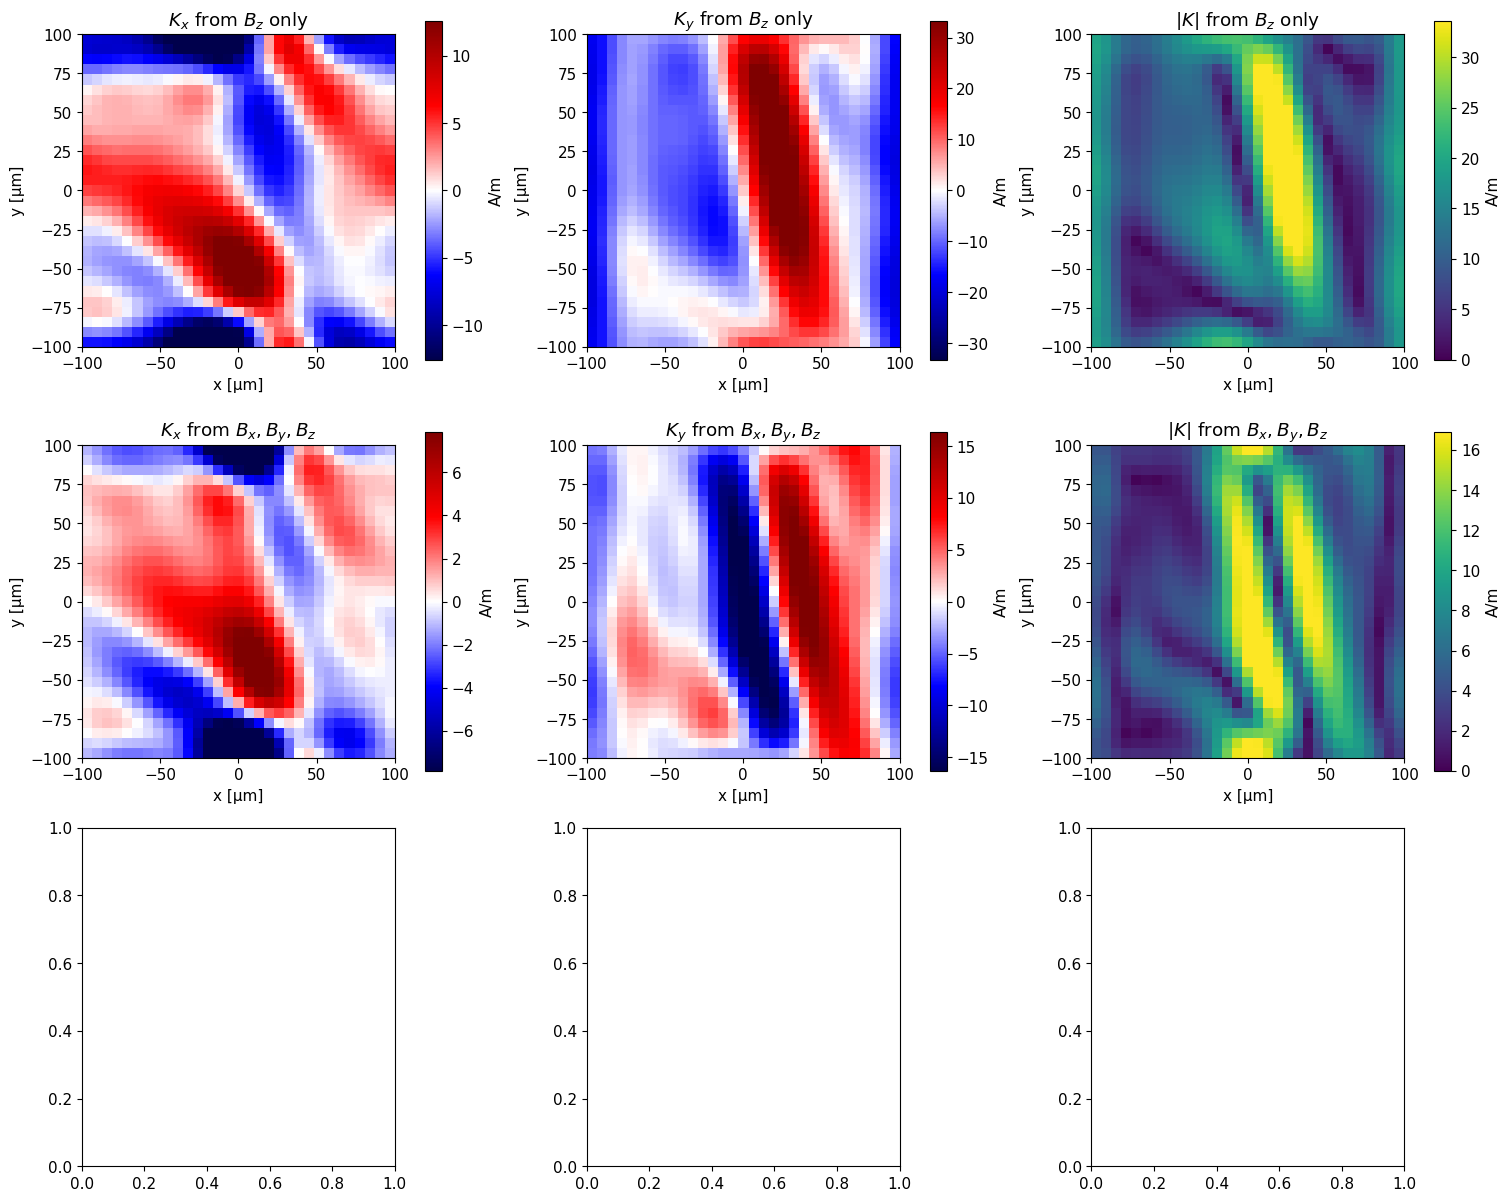

In [ ]:
# ============================================================
# Plot Bz-only, Bxy-only, and Bxyz current reconstructions
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

plot_rows = [
    (Kx_Bz_A_per_m, Ky_Bz_A_per_m, Kmag_Bz_A_per_m, r"from $B_z$ only"),
    (Kx_Bxyz_A_per_m, Ky_Bxyz_A_per_m, Kmag_Bxyz_A_per_m, r"from $B_x,B_y,B_z$"),
]

for row, (Kx_map, Ky_map, Kmag_map, label) in enumerate(plot_rows):
    maps = [
        (Kx_map, rf"$K_x$ {label}", "seismic"),
        (Ky_map, rf"$K_y$ {label}", "seismic"),
        (Kmag_map, rf"$|K|$ {label}", "viridis"),
    ]

    for col, (data, title, cmap) in enumerate(maps):
        ax = axes[row, col]

        if cmap == "viridis":
            vmin = 0.0
            vmax = np.nanpercentile(data, 95)
        else:
            lim = np.nanpercentile(np.abs(data), 95)
            vmin = -lim
            vmax = lim

        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

        im = ax.imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("x [µm]")
        ax.set_ylabel("y [µm]")
        plt.colorbar(im, ax=ax, label="A/m")

plt.show()

In [ ]:
# ============================================================
# Optional diagnostic: reconstruct from POS and NEG separately
# ============================================================

Kx_pos_A_per_m, Ky_pos_A_per_m, Kmag_pos_A_per_m = reconstruct_current_from_Bxyz_streamfunction(
    Bx_nT=B_pos_nT[0],
    By_nT=B_pos_nT[1],
    Bz_nT=B_pos_nT[2],
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
    component_weights=(1.0, 1.0, 1.0),
    side_sign=+1.0,
)

Kx_neg_A_per_m, Ky_neg_A_per_m, Kmag_neg_A_per_m = reconstruct_current_from_Bxyz_streamfunction(
    Bx_nT=B_neg_nT[0],
    By_nT=B_neg_nT[1],
    Bz_nT=B_neg_nT[2],
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
    component_weights=(1.0, 1.0, 1.0),
    side_sign=+1.0,
)

# They should be approximately opposite if the current response dominates.
corr_Kx = np.corrcoef(Kx_pos_A_per_m.ravel(), (-Kx_neg_A_per_m).ravel())[0, 1]
corr_Ky = np.corrcoef(Ky_pos_A_per_m.ravel(), (-Ky_neg_A_per_m).ravel())[0, 1]
corr_Kmag = np.corrcoef(Kmag_pos_A_per_m.ravel(), Kmag_neg_A_per_m.ravel())[0, 1]

print("POS/NEG current reconstruction consistency")
print("------------------------------------------")
print(f"corr(Kx_pos, -Kx_neg) = {corr_Kx:.3f}")
print(f"corr(Ky_pos, -Ky_neg) = {corr_Ky:.3f}")
print(f"corr(|K|_pos, |K|_neg) = {corr_Kmag:.3f}")

POS/NEG current reconstruction consistency
------------------------------------------
corr(Kx_pos, -Kx_neg) = 0.635
corr(Ky_pos, -Ky_neg) = 0.738
corr(|K|_pos, |K|_neg) = 0.624
